---
title: Injective Periodic Functions
subtitle: Implementated using Constrained Monotonic Neural Networks
date: 2025-03-27
---

Please click the power ⏻ button to start a kernel to be able to execute code on this webpage. To
start a separate binder notebook click the rocket icon on the top.

To run code cells click the ▶ button available on the right side of code cells upon hover (when a
kernel is running).

Make sure to run the cells below to install dependencies.

In [1]:
# To experience basic features
%pip install numpy
%pip install matplotlib
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# If you want to do in-browser network training
%pip install svg.path
%pip install torch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Implementation
We first do a basic implementation of an Injective Network.

### Implementation

In [3]:
import torch
from torch import nn

from NIGnets.monotonic_nets import ConstrainedLinear, MonoActivation, MonoDense, MonoNet

In [4]:
x = torch.abs(torch.randn(128, 4))
y = ConstrainedLinear(4, 8)(x)
assert y.shape == (x.shape[0], 8)

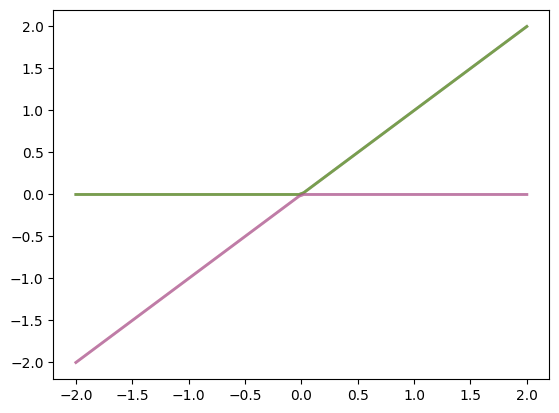

In [5]:
import matplotlib.pyplot as plt

x = torch.hstack([torch.linspace(-2, 2, 100).reshape((-1, 1)) for _ in range(5)])
assert x.shape == (100, 5)
layer = MonoActivation(torch.relu)
y = layer(x)
assert y.shape == (100, 5)

for i in range(5):
    plt.plot(x[:, i], y[:, i], alpha=0.5, linewidth=2)
plt.show()


In [6]:
t = torch.linspace(0, 1, 8).reshape(-1, 4)-.5
x = ConstrainedLinear(4, 6)(t)
y = MonoActivation(torch.relu)(x)
z = MonoDense(4, 6, act_fn=torch.relu)(t)
zz = MonoDense(4, 6, act_fn=None)(t)

t, x, y, z, zz

(tensor([[-0.5000, -0.3571, -0.2143, -0.0714],
         [ 0.0714,  0.2143,  0.3571,  0.5000]]),
 tensor([[-0.3863, -0.4587,  0.0116,  0.1009,  0.1386, -0.7654],
         [ 0.0319,  0.4348,  0.6857,  0.3271,  0.5106, -0.1826]],
        grad_fn=<AddmmBackward0>),
 tensor([[ 0.0000,  0.0000,  0.0116, -0.0000, -0.0000, -0.7654],
         [ 0.0319,  0.4348,  0.6857, -0.0000, -0.0000, -0.1826]],
        grad_fn=<CatBackward0>),
 tensor([[ 0.0000,  0.0000,  0.0616, -0.3978, -0.6122, -0.0776],
         [ 0.9609,  0.3369,  0.6141, -0.0000, -0.0000, -0.0000]],
        grad_fn=<CatBackward0>),
 tensor([[-0.5156,  0.1048, -0.1541, -0.3722,  0.0747, -0.4781],
         [ 0.3939,  0.4795,  0.6945, -0.0775,  0.4903,  0.2225]],
        grad_fn=<AddmmBackward0>))

In [7]:
mono_net = MonoNet(in_features=1, out_features=1, hidden_widths=[16]*2, act_fn=nn.ReLU())
mono_net

MonoNet(
  (0): MonoDense(
    (linear): ConstrainedLinear(in_features=1, out_features=16, bias=True)
    (activation): MonoActivation(
      self.act_fn=ReLU(), self.curvature=None
      (act_fn): ReLU()
    )
  )
  (1): MonoDense(
    (linear): ConstrainedLinear(in_features=16, out_features=16, bias=True)
    (activation): MonoActivation(
      self.act_fn=ReLU(), self.curvature=None
      (act_fn): ReLU()
    )
  )
  (2): MonoDense(
    (linear): ConstrainedLinear(in_features=16, out_features=1, bias=True)
    (activation): MonoActivation(self.act_fn=None, self.curvature=None)
  )
)

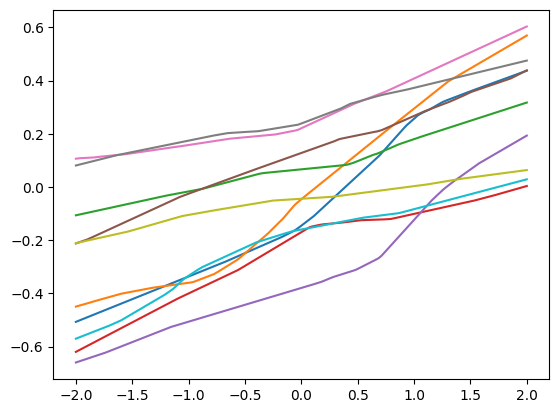

In [8]:
from torch import nn

def plot(net, *, in_features:int=1, out_features:int=1, in_feature: int=0, out_feature: int=0, num_points: int=200):
    x_feature = torch.linspace(-2, 2, num_points).reshape((-1, 1))
    x_zeros_left = torch.zeros((num_points, in_feature))
    x_zeros_right = torch.zeros((num_points, in_features-in_feature-1))
    x = torch.hstack([x_zeros_left, x_feature, x_zeros_right])

    y = net(x)

    plt.plot(x[:, in_feature].detach().numpy(), y[:, out_feature].detach().numpy())

in_features = 3
out_features = 4
in_feature = 2
for _ in range(10):
    mono_net = MonoNet(in_features=in_features, out_features=out_features, hidden_widths=[8]*2, act_fn=nn.ReLU())
    plot(mono_net, in_features=in_features, in_feature=in_feature, out_features=out_features)
plt.show()



In [9]:
from NIGnets import Injective2DNet

injective_net = Injective2DNet(n_hiden_layers=2, hidden_width=8)
injective_net

Injective2DNet(
  (mono_mixed_transforms): MonoNet(
    (0): MonoDense(
      (linear): ConstrainedLinear(in_features=4, out_features=8, bias=True)
      (activation): MonoActivation(
        self.act_fn=ReLU(), self.curvature=None
        (act_fn): ReLU()
      )
    )
    (1): MonoDense(
      (linear): ConstrainedLinear(in_features=8, out_features=8, bias=True)
      (activation): MonoActivation(
        self.act_fn=ReLU(), self.curvature=None
        (act_fn): ReLU()
      )
    )
    (2): MonoDense(
      (linear): ConstrainedLinear(in_features=8, out_features=2, bias=True)
      (activation): MonoActivation(self.act_fn=None, self.curvature=None)
    )
  )
)

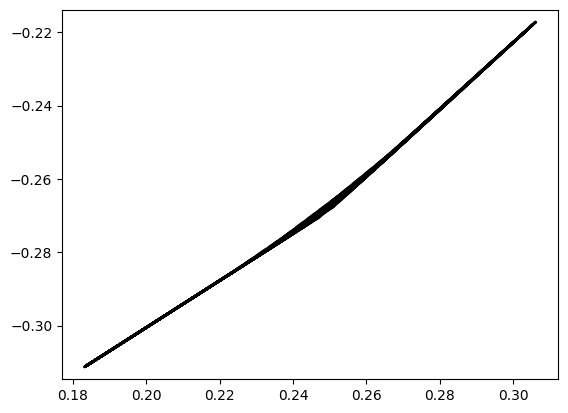

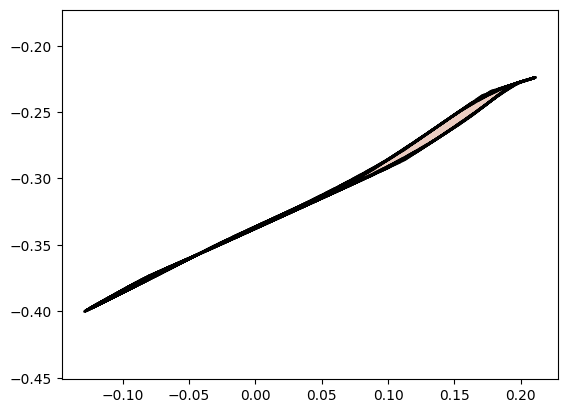

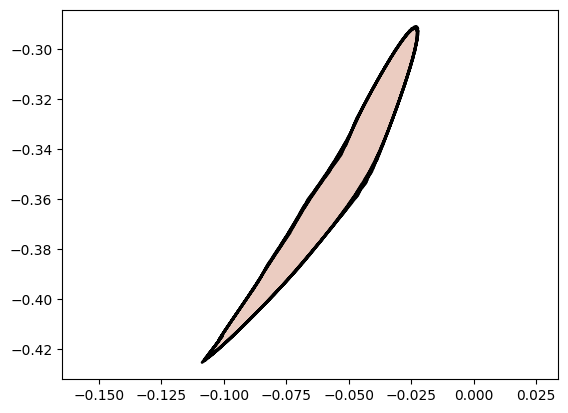

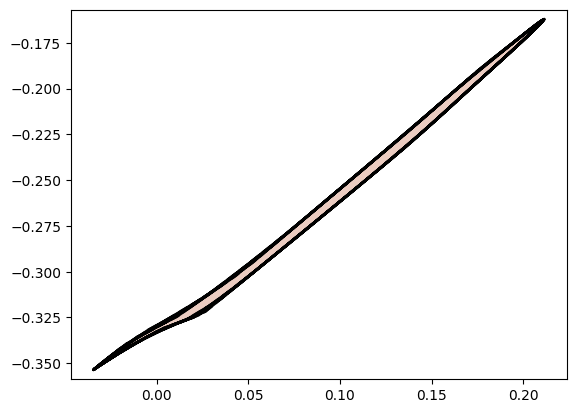

In [10]:
import geosimilarity as gs
from assets.shapes import circle, square
from assets.utils import automate_training, plot_curves

for _ in range(4):
    t = torch.linspace(-2, 2, 100).reshape(-1, 1)
    injective_net = Injective2DNet(n_hiden_layers=2, hidden_width=8)
    Xrandom = injective_net(t)
    plot_curves(Xrandom, Xrandom)


Now we train Injective Networks to fit target shapes. In particular we use loss functions from the
[geosimilarity](https://github.com/atharvaaalok/geosimilarity) python package. Refer to the
[geosimilarity web tutorial](https://atharvaaalok.github.io/geosimilarity/) on API reference and
available geometric loss functions. We use shapes from the
[shapes](https://github.com/atharvaaalok/NIGnets/blob/main/docs/assets/shapes.py) python module. We
will use a circle and square as target shapes and the Mean Squared Error (MSE) loss function to
quantify the difference between the parameterized and the target curve.

We also use the
[automate_training](https://github.com/atharvaaalok/NIGnets/blob/main/docs/assets/utils.py)
[^automate_training] function to hide the training details and focus on the parameterization. The
[plot_curve](https://github.com/atharvaaalok/NIGnets/blob/main/docs/assets/utils.py) function plots
the target and the parameterized curves and abstracts away the plotting details.

[^automate_training]: The code used for automating the training of Networks is:
    :::{literalinclude} assets/utils.py
    :start-at: automate_training
    :end-at: print(
    :::

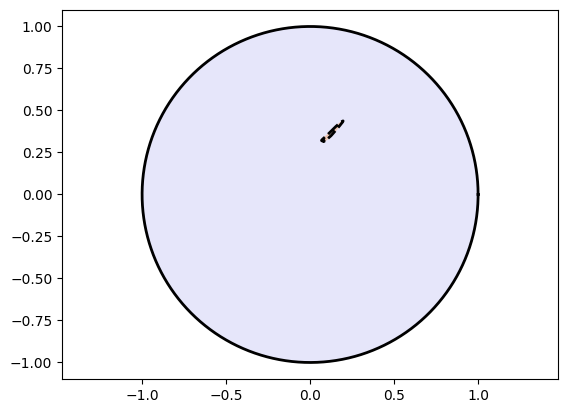

Training Circle Net:
Epoch: [   1/1000]. Loss:    0.575282
Epoch: [ 200/1000]. Loss:    0.000054
Epoch: [ 400/1000]. Loss:    0.000022
Epoch: [ 600/1000]. Loss:    0.000015
Epoch: [ 800/1000]. Loss:    0.000011
Epoch: [1000/1000]. Loss:    0.000009


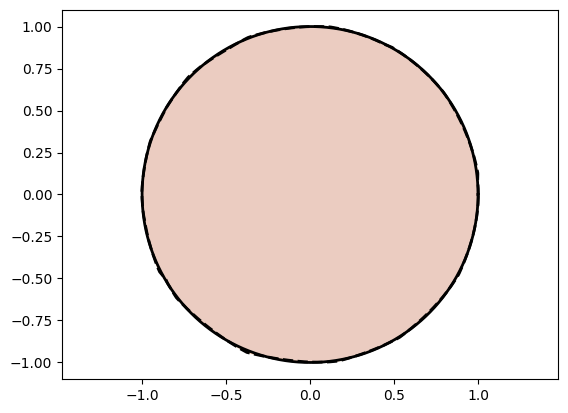

In [11]:
import geosimilarity as gs
from assets.shapes import circle, square
from assets.utils import automate_training, plot_curves

# Generate target curve points
num_pts = 1000
t = torch.linspace(0, 1, num_pts).reshape(-1, 1)
Xt_circle = circle(num_pts)

# Initialize networks to learn the target shapes and train
circle_net = Injective2DNet(n_hiden_layers = 2, hidden_width=16)

# Get final curve represented by the networks
Xc_circle = circle_net(t)

# Plot the curves
plot_curves(Xc_circle, Xt_circle)

print('Training Circle Net:')
automate_training(
    model = circle_net, loss_fn = gs.MSELoss(), X_train = t, Y_train = Xt_circle,
    learning_rate = 0.01, epochs = 1000, print_cost_every = 200
)
Xc_circle = circle_net(t)
plot_curves(Xc_circle, Xt_circle)



Training Square Net:
Epoch: [   1/5000]. Loss:    0.670753
Epoch: [1000/5000]. Loss:    0.000110
Epoch: [2000/5000]. Loss:    0.000018
Epoch: [3000/5000]. Loss:    0.000012
Epoch: [4000/5000]. Loss:    0.000010
Epoch: [5000/5000]. Loss:    0.000008


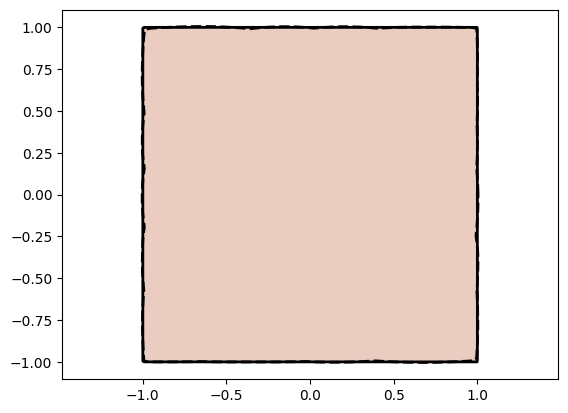

In [12]:
Xt_square = square(num_pts)
square_net = Injective2DNet(n_hiden_layers = 2, hidden_width=32)

Xc_square = square_net(t)
# plot_curves(Xc_square, Xt_square)

print('Training Square Net:')
def f():
    # Get final curve represented by the networks
    Xc_square = square_net(t)

    # Plot the curves
    plot_curves(Xc_square, Xt_square)

automate_training(
    model = square_net, loss_fn = gs.MSELoss(), X_train = t, Y_train = Xt_square,
    learning_rate = 0.01, epochs = 5000, print_cost_every = 1000,
    # f = f
)
f()


Awesome! We see that we are doing good on simple shapes.

Now we move onto something challenging.

Let's test the method on the Stanford Bunny. We will treat the Stanford Bunny as our recurring
evaluation target for different architectures. Therefore we will use a fixed number of points on the
target bunny curve to maintain consistency across curve fitting results.

We now try different `layer_count` and `act_fn` to try and fit the bunny. We recommend you to play
around with the code below to get a good feel for curve fitting capacity of Injective Networks.

Injective2DNet(
  (mono_mixed_transforms): MonoNet(
    (0): MonoDense(
      (linear): ConstrainedLinear(in_features=4, out_features=128, bias=True)
      (activation): MonoActivation(
        self.act_fn=ReLU(), self.curvature=None
        (act_fn): ReLU()
      )
    )
    (1): MonoDense(
      (linear): ConstrainedLinear(in_features=128, out_features=128, bias=True)
      (activation): MonoActivation(
        self.act_fn=ReLU(), self.curvature=None
        (act_fn): ReLU()
      )
    )
    (2): MonoDense(
      (linear): ConstrainedLinear(in_features=128, out_features=2, bias=True)
      (activation): MonoActivation(self.act_fn=None, self.curvature=None)
    )
  )
)
Training Bunny Net:
Epoch: [    1/20000]. Loss:    0.347468
Epoch: [ 2000/20000]. Loss:    0.000152
Epoch: [ 4000/20000]. Loss:    0.000079
Epoch: [ 6000/20000]. Loss:    0.000051
Epoch: [ 8000/20000]. Loss:    0.000033
Epoch: [10000/20000]. Loss:    0.000025
Epoch: [12000/20000]. Loss:    0.000020
Epoch: [14000/20000]

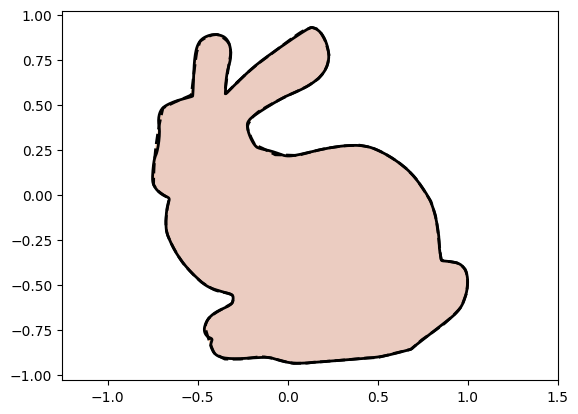

In [16]:
from assets.shapes import stanford_bunny

Xt_bunny = stanford_bunny(num_pts)
bunny_net = Injective2DNet(n_hiden_layers = 2, hidden_width=128)

Xc_bunny = bunny_net(t)

print(bunny_net)

print('Training Bunny Net:')
def f():
    # Get final curve represented by the networks
    Xc_bunny = bunny_net(t)

    # Plot the curves
    plot_curves(Xc_bunny, Xt_bunny)

automate_training(
    model = bunny_net, loss_fn = gs.MSELoss(), X_train = t, Y_train = Xt_bunny,
    learning_rate = 0.003, epochs = 20000, print_cost_every = 2000,
)
f()



In [14]:
def plot_parametrized_curves(net, Xt):
    t = torch.linspace(0, 1, 1000).reshape((-1, 1))
    Xc = net(t)

    t = t[:, 0].detach().numpy()
    plt.plot(t, Xt[:, 0].detach().numpy(), linewidth = 2)
    plt.plot(t, Xt[:, 1].detach().numpy(), linewidth = 2)
    plt.plot(t, Xc[:, 0].detach().numpy(), alpha=0.4, linewidth = 2, linestyle = "--")
    plt.plot(t, Xc[:, 1].detach().numpy(), alpha=0.4, linewidth = 2, linestyle = "--")

    plt.show()



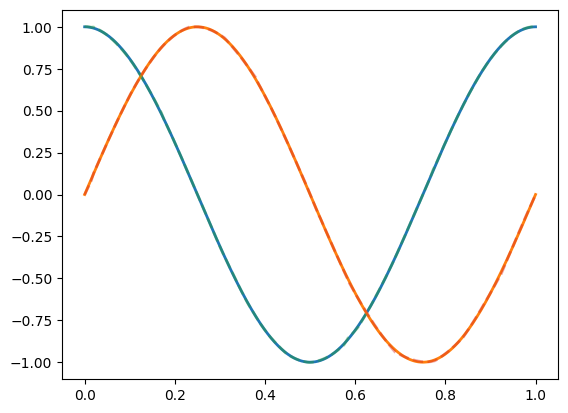

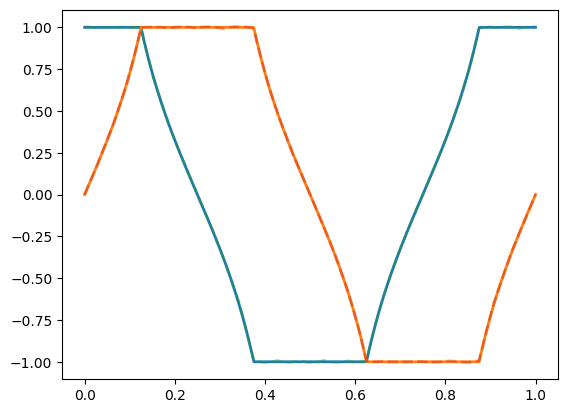

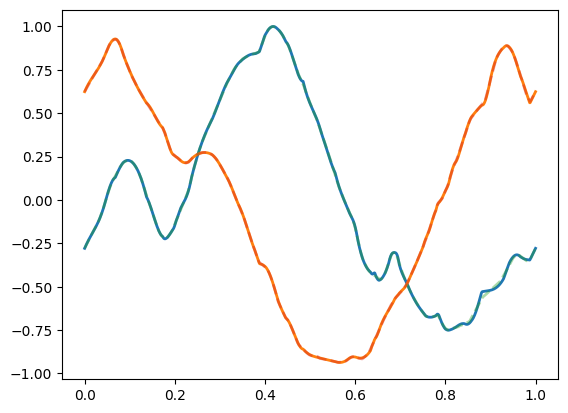

In [15]:
plot_parametrized_curves(circle_net, Xt_circle)
plot_parametrized_curves(square_net, Xt_square)
plot_parametrized_curves(bunny_net, Xt_bunny)
